In [1]:
# CInitial Exploratory Data Analysis and Baseline Filtration
import pandas as pd
import numpy as np

def perform_initial_eda(file_path):
    print("--- Stage 1: Loading Initial Dataset ---")
    df = pd.read_csv(file_path)
    initial_rows = len(df)
    print(f"Total raw verses loaded: {initial_rows}")
    
    # Check if necessary columns exist
    required_cols = ['البحر', 'القافية', 'البيت', 'الشطر الايمن', 'الشطر الايسر']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing critical column: {col}")

    print("\n--- Stage 2: Filtering Standard Khalil Meters ---")
    standard_meters = [
        'الطويل', 'الكامل', 'البسيط', 'الخفيف', 'الوافر', 'الرجز', 
        'الرمل', 'المتقارب', 'السريع', 'المنسرح', 'المجتث', 'المديد', 
        'الهزج', 'المتدارك'
    ]
    
    df_filtered = df[df['البحر'].isin(standard_meters)].copy()
    filtered_rows = len(df_filtered)
    print(f"Verses after applying Khalil meters whitelist: {filtered_rows}")
    print(f"Filtered out {initial_rows - filtered_rows} non-standard rows.")
    
    print("\n--- Stage 3: Meter Distribution Overview ---")
    meter_counts = df_filtered['البحر'].value_counts()
    print(meter_counts.to_string())
    
    print("\n--- Stage 4: Sequence Length Analysis ---")
    # Calculate length based on the full verse
    df_filtered['verse_length'] = df_filtered['البيت'].astype(str).apply(len)
    
    max_len = df_filtered['verse_length'].max()
    min_len = df_filtered['verse_length'].min()
    mean_len = df_filtered['verse_length'].mean()
    
    print(f"Maximum verse length (characters): {max_len}")
    print(f"Minimum verse length (characters): {min_len}")
    print(f"Average verse length (characters): {mean_len:.2f}")
    
    # Identify outliers (e.g., incredibly short or long strings that might be noise)
    outliers = df_filtered[(df_filtered['verse_length'] < 20) | (df_filtered['verse_length'] > 150)]
    print(f"Detected potential length outliers (<20 or >150 chars): {len(outliers)} verses.")
    
    print("\n--- Stage 5: Exporting Clean Baseline ---")
    # Keep only the columns we actually need moving forward to save memory
    final_cols = ['البيت', 'البحر', 'القافية']
    df_baseline = df_filtered[final_cols].copy()
    
    output_path = 'apcd_baseline.csv'
    df_baseline.to_csv(output_path, index=False)
    print(f"Baseline dataset saved successfully to: {output_path}")
    
    return df_baseline

# Execute the EDA function
df_base = perform_initial_eda('/kaggle/input/datasets/mohamedkhaledelsafty/best-arabic-poem-comprehensive-dataset/Arabic PCD/Arabic Poem Comprehensive Dataset (APCD).csv')

--- Stage 1: Loading Initial Dataset ---
Total raw verses loaded: 1831770

--- Stage 2: Filtering Standard Khalil Meters ---
Verses after applying Khalil meters whitelist: 1690584
Filtered out 141186 non-standard rows.

--- Stage 3: Meter Distribution Overview ---
البحر
الطويل      405378
الكامل      363486
البسيط      239974
الخفيف      156049
الوافر      140560
الرجز       117572
الرمل        79015
المتقارب     63818
السريع       58084
المنسرح      28357
المجتث       17884
المديد        7829
الهزج         7541
المتدارك      5037

--- Stage 4: Sequence Length Analysis ---
Maximum verse length (characters): 114
Minimum verse length (characters): 4
Average verse length (characters): 60.26
Detected potential length outliers (<20 or >150 chars): 1554 verses.

--- Stage 5: Exporting Clean Baseline ---
Baseline dataset saved successfully to: apcd_baseline.csv


In [2]:
# Cell 1.5: Deep Cleansing and Noise Reduction
import pandas as pd
import re

def perform_deep_cleansing(input_path, output_path):
    print(f"--- Loading Baseline Data from {input_path} ---")
    df = pd.read_csv(input_path)
    initial_count = len(df)
    
    print("\n1. Dropping NaNs and Duplicates...")
    df.dropna(subset=['البيت', 'البحر', 'القافية'], inplace=True)
    df.drop_duplicates(subset=['البيت'], inplace=True)
    print(f"Removed {initial_count - len(df)} duplicate/null rows.")
    
    print("\n2. Applying Text Normalization (Regex)...")
    def clean_verse(text):
        if not isinstance(text, str):
            return ""
        # Remove Tatweel (Kashida)
        text = re.sub(r'ـ', '', text)
        # Remove everything EXCEPT Arabic letters, diacritics (Tashkeel), and spaces
        # \u0621-\u064A: Arabic Letters
        # \u064B-\u0652: Arabic Diacritics
        text = re.sub(r'[^\u0621-\u064A\u064B-\u0652\s]', '', text)
        # Normalize multiple spaces into a single space
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['البيت'] = df['البيت'].apply(clean_verse)
    
    print("\n3. Enforcing Strict Structural Lengths...")
    # Recalculate length after removing noise/tatweel
    df['verse_length'] = df['البيت'].apply(len)
    
    # Keep verses strictly between 20 and 120 characters
    valid_length_mask = (df['verse_length'] >= 20) & (df['verse_length'] <= 120)
    outliers_count = len(df) - valid_length_mask.sum()
    df = df[valid_length_mask].copy()
    
    print(f"Removed {outliers_count} structurally invalid verses (too short/long).")
    
    print("\n--- Final Dataset Health Check ---")
    final_count = len(df)
    print(f"Final Clean Verses: {final_count}")
    print(f"Total Noise Removed in this stage: {initial_count - final_count} verses.")
    
    # Drop the temporary length column and export
    df.drop(columns=['verse_length'], inplace=True)
    df.to_csv(output_path, index=False)
    print(f"\nGolden Cleaned Dataset saved to: {output_path}")

# Execute Deep Cleansing
perform_deep_cleansing('apcd_baseline.csv', 'apcd_cleaned.csv')

--- Loading Baseline Data from apcd_baseline.csv ---

1. Dropping NaNs and Duplicates...
Removed 3710 duplicate/null rows.

2. Applying Text Normalization (Regex)...

3. Enforcing Strict Structural Lengths...
Removed 3637 structurally invalid verses (too short/long).

--- Final Dataset Health Check ---
Final Clean Verses: 1683237
Total Noise Removed in this stage: 7347 verses.

Golden Cleaned Dataset saved to: apcd_cleaned.csv


In [3]:
# Cell: Enforcing Capped Balancing on Cleaned Data
import pandas as pd

def enforce_capped_balancing(input_csv, output_csv, cap_limit=15000):
    print(f"Loading heavily imbalanced data from {input_csv}...")
    df = pd.read_csv(input_csv)
    
    print("\n--- Original Distribution ---")
    print(df['البحر'].value_counts().to_string())
    
    # Apply capping (downsampling majority classes randomly)
    balanced_df = df.groupby('البحر', group_keys=False).apply(
        lambda x: x.sample(min(len(x), cap_limit), random_state=42)
    ).reset_index(drop=True)
    
    # Shuffle the dataset thoroughly
    balanced_df = balanced_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    
    print(f"\n--- Balanced Distribution (Cap = {cap_limit}) ---")
    print(balanced_df['البحر'].value_counts().to_string())
    print(f"\nTotal Verses after balancing: {len(balanced_df)}")
    
    balanced_df.to_csv(output_csv, index=False)
    print(f"Saved highly balanced dataset to: {output_csv}")

# Execute the balancing
enforce_capped_balancing('apcd_cleaned.csv', 'apcd_balanced_15k.csv', cap_limit=15000)

Loading heavily imbalanced data from apcd_cleaned.csv...

--- Original Distribution ---
البحر
الطويل      404227
الكامل      362224
البسيط      239638
الخفيف      155533
الوافر      140270
الرجز       116636
الرمل        77849
المتقارب     63275
السريع       57795
المنسرح      28187
المجتث       17614
المديد        7757
الهزج         7412
المتدارك      4820


/tmp/ipykernel_55/3543225743.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('البحر', group_keys=False).apply(



--- Balanced Distribution (Cap = 15000) ---
البحر
الطويل      15000
الرمل       15000
المنسرح     15000
الوافر      15000
المتقارب    15000
السريع      15000
المجتث      15000
الخفيف      15000
البسيط      15000
الكامل      15000
الرجز       15000
المديد       7757
الهزج        7412
المتدارك     4820

Total Verses after balancing: 184989
Saved highly balanced dataset to: apcd_balanced_15k.csv


In [4]:
# Cell 3 (Updated): Character-Level Data Engineering with Natural Augmentation
import pandas as pd
import numpy as np
import random
import json
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split

class CharLevelPreprocessor:
    def __init__(self, max_verse_len=150, max_rhyme_len=10):
        self.max_verse_len = max_verse_len
        self.max_rhyme_len = max_rhyme_len
        self.vowels = ['َ', 'ُ', 'ِ']
        self.sukoon = 'ْ'
        self.shadda = 'ّ'
        
        # Comprehensive Vocabulary (Letters + Diacritics)
        self.arabic_alphabet = list("ءآأؤإئابتثجحخدذرزسشصضطظعغفقكلمنهويىةَُِّْ")
        self.char_to_id = {char: idx + 1 for idx, char in enumerate(self.arabic_alphabet)}
        self.vocab_size = len(self.char_to_id) + 1 # +1 for padding (0)

    def encode_full_verse(self, verse):
        """Encodes the entire verse into character IDs."""
        verse_clean = re.sub(r'[^\u0621-\u064A\u064B-\u0652]', '', str(verse))
        encoded = [self.char_to_id.get(c, 0) for c in verse_clean]
        
        if len(encoded) > self.max_verse_len:
            return encoded[:self.max_verse_len]
        return encoded + [0] * (self.max_verse_len - len(encoded))

    def encode_rhyme_chars(self, verse):
        """Encodes only the last characters stripped of diacritics for the Rhyme branch."""
        clean_verse = re.sub(r'[\u064B-\u0652]', '', str(verse)).strip()
        last_chars = list(clean_verse.replace(" ", ""))[-self.max_rhyme_len:]
        encoded_chars = [self.char_to_id.get(c, 0) for c in last_chars]
        
        if len(encoded_chars) < self.max_rhyme_len:
            encoded_chars = [0] * (self.max_rhyme_len - len(encoded_chars)) + encoded_chars
        return encoded_chars

    def inject_natural_error(self, verse):
        """Mutates a diacritic in the text to create a structural rhythmic break."""
        verse_chars = list(str(verse))
        # Find all indices containing a diacritic
        diacritic_indices = [i for i, char in enumerate(verse_chars) if char in self.vowels + [self.sukoon]]
        
        if diacritic_indices:
            idx = random.choice(diacritic_indices)
            if verse_chars[idx] in self.vowels:
                verse_chars[idx] = self.sukoon
            else:
                verse_chars[idx] = random.choice(self.vowels)
                
        return "".join(verse_chars)

def process_char_level_split(df, processor, meter_mapping, rhyme_mapping, corruption_rate, split_name):
    processed_data = []
    print(f"Processing and augmenting {split_name} split...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        verse = str(row['البيت'])
        m_id = meter_mapping[row['البحر']]
        r_id = rhyme_mapping[row['القافية']]
        
        base_verse_seq = processor.encode_full_verse(verse)
        char_seq = processor.encode_rhyme_chars(verse)
        
        # 1. Correct sample
        processed_data.append({
            'verse_seq': base_verse_seq, 'char_seq': char_seq,
            'meter_label': m_id, 'rhyme_label': r_id, 'error_label': 0.0
        })
        
        # 2. Broken sample (Injected naturally)
        if random.random() < corruption_rate:
            broken_verse = processor.inject_natural_error(verse)
            broken_verse_seq = processor.encode_full_verse(broken_verse)
            processed_data.append({
                'verse_seq': broken_verse_seq, 'char_seq': char_seq,
                'meter_label': m_id, 'rhyme_label': r_id, 'error_label': 1.0
            })
            
    return pd.DataFrame(processed_data)

def build_char_level_dataset(input_csv, corruption_rate=0.3):
    print(f"Loading balanced dataset from {input_csv}...")
    df = pd.read_csv(input_csv)
    processor = CharLevelPreprocessor()
    
    meter_mapping = {m: i for i, m in enumerate(sorted(df['البحر'].unique()))}
    df['القافية'] = df['القافية'].replace(['أ', 'إ', 'آ', 'ؤ', 'ئ'], 'ء').replace('ة', 'ه')
    rhyme_mapping = {r: i for i, r in enumerate(sorted(df['القافية'].dropna().unique()))}
    
    with open('dl_meter_mapping.json', 'w') as f: json.dump(meter_mapping, f)
    with open('dl_rhyme_mapping.json', 'w') as f: json.dump(rhyme_mapping, f)
    
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['البحر'])
    val_df, test_df = train_test_split(temp_df, test_size=(20/30), random_state=42, stratify=temp_df['البحر'])
    
    train_out = process_char_level_split(train_df, processor, meter_mapping, rhyme_mapping, corruption_rate, "Train")
    train_out.to_json('train_char_mtl.jsonl', orient='records', lines=True)
    
    val_out = process_char_level_split(val_df, processor, meter_mapping, rhyme_mapping, corruption_rate, "Validation")
    val_out.to_json('val_char_mtl.jsonl', orient='records', lines=True)

    test_out = process_char_level_split(test_df, processor, meter_mapping, rhyme_mapping, corruption_rate, "Test")
    test_out.to_json('test_char_mtl.jsonl', orient='records', lines=True)
    
    print(f"\nTotal Vocab Size Generated: {processor.vocab_size}")
    print("Data Engineering Complete! Ready for the new Architecture.")

# IMPORTANT: Run this on the capped balanced dataset (e.g., apcd_balanced_15k.csv)
build_char_level_dataset('apcd_balanced_15k.csv', corruption_rate=0.3)

Loading balanced dataset from apcd_balanced_15k.csv...
Processing and augmenting Train split...


100%|██████████| 129492/129492 [00:10<00:00, 12698.60it/s]


Processing and augmenting Validation split...


100%|██████████| 18499/18499 [00:01<00:00, 14188.11it/s]


Processing and augmenting Test split...


100%|██████████| 36998/36998 [00:03<00:00, 11829.59it/s]



Total Vocab Size Generated: 42
Data Engineering Complete! Ready for the new Architecture.


In [5]:
# Cell 4 (Updated): SOTA Character-Level Bifurcated Architecture
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attn_weights = self.attention(lstm_output)
        attn_weights = F.softmax(attn_weights, dim=1) 
        context_vector = torch.sum(attn_weights * lstm_output, dim=1)
        return context_vector, attn_weights

class SOTA_ArabPoetDualModel(nn.Module):
    def __init__(self, vocab_size, num_meters=14, num_rhymes=34, embed_dim=64):
        super(SOTA_ArabPoetDualModel, self).__init__()
        
        # Shared Character Embedding Layer
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        
        # ==========================================
        # 1. Meter Branch (Pure Sequential + Attention)
        # ==========================================
        self.meter_lstm = nn.LSTM(input_size=embed_dim, hidden_size=128, num_layers=2, 
                                 batch_first=True, bidirectional=True, dropout=0.3)
        self.meter_attention = Attention(hidden_dim=256)
        
        # ==========================================
        # 2. Error Branch (CNN-based Anomaly Detection)
        # ==========================================
        self.error_conv = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5, padding=2)
        self.error_relu = nn.ReLU()
        self.error_pool = nn.MaxPool1d(kernel_size=2)
        self.error_lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=1, 
                                 batch_first=True, bidirectional=True)
        
        # ==========================================
        # 3. Rhyme Branch (Character-Level Tail)
        # ==========================================
        self.rhyme_conv = nn.Conv1d(in_channels=embed_dim, out_channels=64, kernel_size=3, padding=1)
        self.rhyme_relu = nn.ReLU()
        
        self.dropout = nn.Dropout(0.4)
        
        # ==========================================
        # Task-Specific Heads
        # ==========================================
        self.meter_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_meters)
        )
        
        self.error_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
        self.rhyme_head = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_rhymes)
        )

    def forward(self, verse_seq, char_seq):
        # verse_seq shape: (Batch, 150) | char_seq shape: (Batch, 10)
        
        # 1. Embeddings
        verse_embed = self.embedding(verse_seq) # (Batch, 150, 64)
        rhyme_embed = self.embedding(char_seq)  # (Batch, 10, 64)
        
        # --- Meter Path ---
        meter_lstm_out, _ = self.meter_lstm(verse_embed)
        meter_features, _ = self.meter_attention(meter_lstm_out)
        meter_features = self.dropout(meter_features)
        
        # --- Error Path ---
        # Permute for Conv1d: (Batch, Channels, Length) -> (Batch, 64, 150)
        x_error = verse_embed.permute(0, 2, 1) 
        x_error = self.error_conv(x_error)
        x_error = self.error_relu(x_error)
        x_error = self.error_pool(x_error)
        x_error = x_error.permute(0, 2, 1) # Back to (Batch, Length, Channels)
        error_lstm_out, _ = self.error_lstm(x_error)
        error_features, _ = torch.max(error_lstm_out, dim=1)
        error_features = self.dropout(error_features)

        # --- Rhyme Path ---
        x_rhyme = rhyme_embed.permute(0, 2, 1) # (Batch, 64, 10)
        x_rhyme = self.rhyme_conv(x_rhyme)
        x_rhyme = self.rhyme_relu(x_rhyme)
        char_features, _ = torch.max(x_rhyme, dim=2)
        char_features = self.dropout(char_features)

        # --- Predictions ---
        meter_logits = self.meter_head(meter_features)
        error_logits = self.error_head(error_features)
        rhyme_logits = self.rhyme_head(char_features)
        
        return meter_logits, rhyme_logits, error_logits

In [6]:
# Cell 5: The Ultimate SOTA MTL Training Engine (Self-Contained)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import copy
import random
from tqdm import tqdm
import json

# -----------------------------------------
# 1. Focal Loss & Dynamic Weighting
# -----------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class DynamicMTLFocalLoss(nn.Module):
    def __init__(self, num_tasks=3):
        super(DynamicMTLFocalLoss, self).__init__()
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))
        self.meter_loss_fn = FocalLoss(gamma=2.5, label_smoothing=0.1)
        
    def forward(self, logits, targets):
        m_logits, r_logits, e_logits = logits
        m_target, r_target, e_target = targets
        
        loss_m = self.meter_loss_fn(m_logits, m_target)
        loss_r = F.cross_entropy(r_logits, r_target)
        loss_e = F.binary_cross_entropy_with_logits(e_logits.squeeze(), e_target)
        
        losses = [loss_m, loss_r, loss_e]
        weighted_losses = []
        
        for i, loss in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            weighted_losses.append((precision * loss) + self.log_vars[i])
            
        return weighted_losses

# -----------------------------------------
# 2. Dataset Loader (Character-Level)
# -----------------------------------------
class DualInputDataset(Dataset):
    def __init__(self, jsonl_file):
        print(f"Loading {jsonl_file} into RAM...")
        self.data = pd.read_json(jsonl_file, lines=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return {
            'verse_seq': torch.tensor(row['verse_seq'], dtype=torch.long),
            'char_seq': torch.tensor(row['char_seq'], dtype=torch.long),
            'meter_label': torch.tensor(row['meter_label'], dtype=torch.long),
            'rhyme_label': torch.tensor(row['rhyme_label'], dtype=torch.long),
            'error_label': torch.tensor(row['error_label'], dtype=torch.float)
        }

# -----------------------------------------
# 3. PCGrad Optimizer Wrapper
# -----------------------------------------
class PCGrad:
    def __init__(self, optimizer):
        self.optimizer = optimizer

    def zero_grad(self):
        self.optimizer.zero_grad()

    def step(self):
        self.optimizer.step()

    def pc_backward(self, objectives):
        grads, shapes, has_grads = self._pack_grad(objectives)
        pc_grad = self._project_conflicting(grads, has_grads)
        pc_grad = self._unflatten_grad(pc_grad, shapes[0])
        self._set_grad(pc_grad)

    def _project_conflicting(self, grads, has_grads):
        pc_grad = copy.deepcopy(grads)
        for g_i in pc_grad:
            random.shuffle(grads)
            for g_j in grads:
                g_i_g_j = torch.dot(g_i, g_j)
                if g_i_g_j < 0:
                    g_i -= (g_i_g_j) * g_j / (g_j.norm()**2)
        return torch.stack(pc_grad).sum(0)

    def _pack_grad(self, objectives):
        grads, shapes, has_grads = [], [], []
        for obj in objectives:
            self.optimizer.zero_grad(set_to_none=True)
            obj.backward(retain_graph=True)
            grad, shape, has_grad = self._retrieve_grad()
            grads.append(self._flatten_grad(grad, shape))
            has_grads.append(self._flatten_grad(has_grad, shape))
            shapes.append(shape)
        return grads, shapes, has_grads

    def _retrieve_grad(self):
        grad, shape, has_grad = [], [], []
        for group in self.optimizer.param_groups:
            for p in group['params']:
                if p.grad is None:
                    shape.append(p.shape)
                    grad.append(torch.zeros_like(p).to(p.device))
                    has_grad.append(torch.zeros_like(p).to(p.device))
                else:
                    shape.append(p.grad.shape)
                    grad.append(p.grad.clone())
                    has_grad.append(torch.ones_like(p).to(p.device))
        return grad, shape, has_grad

    def _flatten_grad(self, grads, shapes):
        return torch.cat([g.flatten() for g in grads])

    def _unflatten_grad(self, grads, shapes):
        unflatten_grad, idx = [], 0
        for shape in shapes:
            length = torch.prod(torch.tensor(shape))
            unflatten_grad.append(grads[idx:idx + length].view(shape).clone())
            idx += length
        return unflatten_grad

    def _set_grad(self, grads):
        idx = 0
        for group in self.optimizer.param_groups:
            for p in group['params']:
                p.grad = grads[idx]
                idx += 1

# Updated Training Loop for 90%+ Accuracy (Fixed PyTorch Version Compatibility)
def train_dual_model_sota(epochs=30, batch_size=256, embed_dim=128):
    with open('dl_meter_mapping.json', 'r') as f: num_meters = len(json.load(f))
    with open('dl_rhyme_mapping.json', 'r') as f: num_rhymes = len(json.load(f))
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--- Initialization ---")
    print(f"Device: {device} | Batch Size: {batch_size} | Embed Dim: {embed_dim}")

    # 1. Increased embed_dim to 128 for richer morphological representation
    model = SOTA_ArabPoetDualModel(vocab_size=43, num_meters=num_meters, num_rhymes=num_rhymes, embed_dim=embed_dim)
    
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
        
    model = model.to(device)
    
    loss_fn = DynamicMTLFocalLoss(num_tasks=3).to(device)
    
    base_opt = optim.AdamW(list(model.parameters()) + list(loss_fn.parameters()), lr=1e-3, weight_decay=1e-4)
    optimizer = PCGrad(base_opt)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(base_opt, mode='min', factor=0.5, patience=3)
    
    train_dataset = DualInputDataset('train_char_mtl.jsonl')
    val_dataset = DualInputDataset('val_char_mtl.jsonl')
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    best_val_loss = float('inf')
    
    print("\n--- Starting Final Breakthrough Training ---")
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in progress_bar:
            verse_seq = batch['verse_seq'].to(device, non_blocking=True)
            char_seq = batch['char_seq'].to(device, non_blocking=True)
            targets = (
                batch['meter_label'].to(device, non_blocking=True),
                batch['rhyme_label'].to(device, non_blocking=True),
                batch['error_label'].to(device, non_blocking=True)
            )
            
            optimizer.zero_grad()
            logits = model(verse_seq, char_seq)
            losses = loss_fn(logits, targets)
            
            optimizer.pc_backward(losses)
            # Prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            step_loss = sum(losses).item()
            total_train_loss += step_loss
            progress_bar.set_postfix({'loss': f"{step_loss:.4f}"})
            
        avg_train_loss = total_train_loss / len(train_loader)
        
        # Validation Phase
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                verse_seq = batch['verse_seq'].to(device, non_blocking=True)
                char_seq = batch['char_seq'].to(device, non_blocking=True)
                targets = (
                    batch['meter_label'].to(device),
                    batch['rhyme_label'].to(device),
                    batch['error_label'].to(device)
                )
                logits = model(verse_seq, char_seq)
                losses = loss_fn(logits, targets)
                total_val_loss += sum(losses).item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        
        # 3. Step the scheduler based on validation loss
        scheduler.step(avg_val_loss)
        
        current_lr = base_opt.param_groups[0]['lr']
        print(f"End of Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")
        
        # 4. Save only the BEST model to prevent overfitting saving
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint_name = f"hybrid_mtl_best_sota.pt"
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state_dict, checkpoint_name)
            print(f"*** New Best Model Saved: {checkpoint_name} ***\n")
        else:
            print("\n")

# Execute
train_dual_model_sota(epochs=15, batch_size=256, embed_dim=128)

--- Initialization ---
Device: cuda | Batch Size: 256 | Embed Dim: 128
Using 2 GPUs!
Loading train_char_mtl.jsonl into RAM...
Loading val_char_mtl.jsonl into RAM...

--- Starting Final Breakthrough Training ---


Epoch 1/30 [Val]: 100%|██████████| 94/94 [00:02<00:00, 35.47it/s]


End of Epoch 1 | Train Loss: 3.4583 | Val Loss: 2.2506 | LR: 0.001000
*** New Best Model Saved: hybrid_mtl_best_sota.pt ***



Epoch 2/30 [Val]: 100%|██████████| 94/94 [00:02<00:00, 34.91it/s]


End of Epoch 2 | Train Loss: 2.1595 | Val Loss: 1.6890 | LR: 0.001000
*** New Best Model Saved: hybrid_mtl_best_sota.pt ***



...

End of Epoch 28 | Train Loss: -0.9315 | Val Loss: 1.0197 | LR: 0.000063




Epoch 29/30 [Val]: 100%|██████████| 94/94 [00:02<00:00, 32.74it/s]


End of Epoch 29 | Train Loss: -0.9488 | Val Loss: 1.0954 | LR: 0.000063




Epoch 30/30 [Val]: 100%|██████████| 94/94 [00:02<00:00, 33.39it/s]


End of Epoch 30 | Train Loss: -0.9606 | Val Loss: 1.1227 | LR: 0.000063




In [7]:
# Cell 6: Comprehensive Model Evaluation on Test Set (Fixed for embed_dim=128)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
import json
import warnings
warnings.filterwarnings('ignore')

def evaluate_model_metrics_sota(model_path, test_file, batch_size=256, embed_dim=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--- Starting Evaluation on {device} ---")
    
    # Load mapping sizes dynamically
    with open('dl_meter_mapping.json', 'r') as f: 
        meter_map = json.load(f)
        num_meters = len(meter_map)
        rev_meter_map = {v: k for k, v in meter_map.items()}
        
    with open('dl_rhyme_mapping.json', 'r') as f: 
        rhyme_map = json.load(f)
        num_rhymes = len(rhyme_map)
        rev_rhyme_map = {v: k for k, v in rhyme_map.items()}

    # CRITICAL FIX: Pass embed_dim=128 to match the trained checkpoint
    model = SOTA_ArabPoetDualModel(vocab_size=43, num_meters=num_meters, num_rhymes=num_rhymes, embed_dim=embed_dim)
    
    # Handle DataParallel if the model was saved using multiple GPUs
    state_dict = torch.load(model_path, map_location=device)
    # Remove 'module.' prefix if it exists (caused by DataParallel)
    clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(clean_state_dict)
    
    model = model.to(device)
    model.eval() # Set to evaluation mode
    
    # Load Test Data 
    test_dataset = DualInputDataset(test_file)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # Lists to store ground truth and predictions
    true_m, pred_m = [], []
    true_r, pred_r = [], []
    true_e, pred_e = [], []
    
    print(f"Evaluating {len(test_dataset)} samples...")
    with torch.no_grad():
        for batch in test_loader:
            verse_seq = batch['verse_seq'].to(device)
            char_seq = batch['char_seq'].to(device)
            
            m_logits, r_logits, e_logits = model(verse_seq, char_seq)
            
            # Meter Predictions (Argmax)
            m_preds = torch.argmax(m_logits, dim=1).cpu().numpy()
            true_m.extend(batch['meter_label'].numpy())
            pred_m.extend(m_preds)
            
            # Rhyme Predictions (Argmax)
            r_preds = torch.argmax(r_logits, dim=1).cpu().numpy()
            true_r.extend(batch['rhyme_label'].numpy())
            pred_r.extend(r_preds)
            
            # Error Predictions (Sigmoid > 0.5)
            e_probs = torch.sigmoid(e_logits).squeeze()
            e_preds = (e_probs > 0.5).long().cpu().numpy()
            true_e.extend(batch['error_label'].long().numpy())
            pred_e.extend(e_preds)

    # Calculate Accuracies
    acc_meter = accuracy_score(true_m, pred_m)
    acc_rhyme = accuracy_score(true_r, pred_r)
    acc_error = accuracy_score(true_e, pred_e)
    
    print("\n==============================================")
    print("         FINAL SOTA TEST SET PERFORMANCE")
    print("==============================================")
    print(f"1. Meter Classification Accuracy : {acc_meter * 100:.2f}%")
    print(f"2. Rhyme Classification Accuracy : {acc_rhyme * 100:.2f}%")
    print(f"3. Error Detection Accuracy      : {acc_error * 100:.2f}%")
    print("==============================================\n")
    
    target_names = [rev_meter_map[i] for i in range(num_meters)]
    print("Detailed Meter Classification Report:")
    print(classification_report(true_m, pred_m, target_names=target_names, zero_division=0))

# Execute evaluation with the correct checkpoint name
evaluate_model_metrics_sota('hybrid_mtl_best_sota.pt', 'test_char_mtl.jsonl')

--- Starting Evaluation on cuda ---
Loading test_char_mtl.jsonl into RAM...
Evaluating 48084 samples...

         FINAL SOTA TEST SET PERFORMANCE
1. Meter Classification Accuracy : 89.06%
2. Rhyme Classification Accuracy : 87.95%
3. Error Detection Accuracy      : 89.83%

Detailed Meter Classification Report:
              precision    recall  f1-score   support

      البسيط       0.93      0.93      0.93      3900
      الخفيف       0.88      0.92      0.90      3898
       الرجز       0.84      0.72      0.78      3885
       الرمل       0.87      0.86      0.86      3893
      السريع       0.88      0.86      0.87      3917
      الطويل       0.94      0.95      0.95      3868
      الكامل       0.82      0.89      0.85      3971
    المتدارك       0.84      0.82      0.83      1234
    المتقارب       0.93      0.93      0.93      3951
      المجتث       0.88      0.94      0.91      3901
      المديد       0.90      0.86      0.88      1999
     المنسرح       0.92      0.90      0

--- Starting Post-Training Analysis on cuda ---
Loading test_char_mtl.jsonl into RAM...
Gathering predictions...

--- Tuning Error Detection Threshold ---
Default Threshold (0.50) Accuracy: 89.83%
OPTIMAL Threshold (0.40) Accuracy: 89.88%

--- Generating Meter Confusion Matrix ---


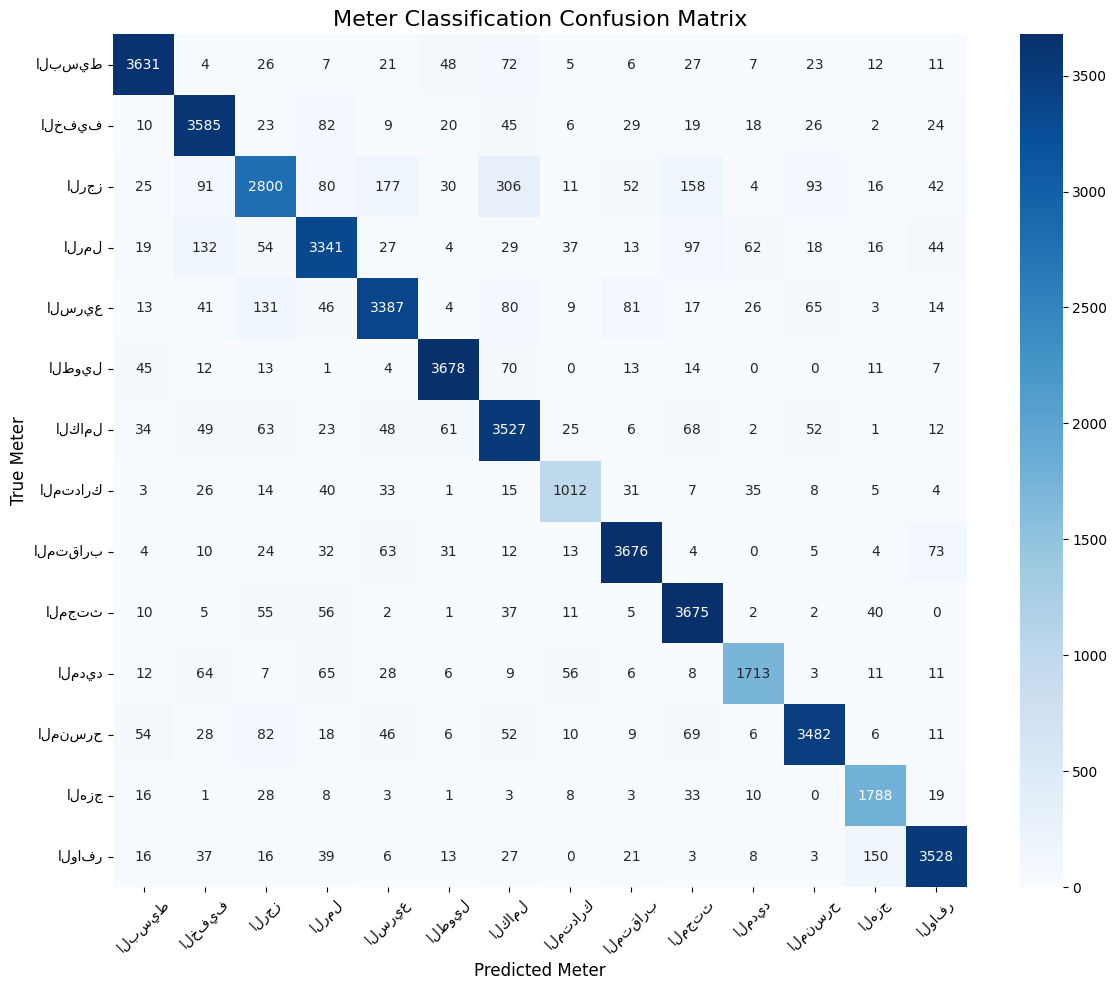

In [8]:
# Cell 7: Post-Training Optimization (Threshold Tuning & Error Analysis)
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

def optimize_and_analyze(model_path, test_file, batch_size=256):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--- Starting Post-Training Analysis on {device} ---")
    
    with open('dl_meter_mapping.json', 'r') as f: 
        meter_map = json.load(f)
        num_meters = len(meter_map)
        rev_meter_map = {v: k for k, v in meter_map.items()}
        
    with open('dl_rhyme_mapping.json', 'r') as f: 
        rhyme_map = json.load(f)
        num_rhymes = len(rhyme_map)
        
    # Load Model
    model = SOTA_ArabPoetDualModel(vocab_size=43, num_meters=num_meters, num_rhymes=num_rhymes, embed_dim=128)
    state_dict = torch.load(model_path, map_location=device)
    clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(clean_state_dict)
    model.to(device)
    model.eval()
    
    test_dataset = DualInputDataset(test_file)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    true_m, pred_m = [], []
    true_e, prob_e = [], []
    
    print("Gathering predictions...")
    with torch.no_grad():
        for batch in test_loader:
            verse_seq = batch['verse_seq'].to(device)
            char_seq = batch['char_seq'].to(device)
            
            m_logits, r_logits, e_logits = model(verse_seq, char_seq)
            
            # Meter
            m_preds = torch.argmax(m_logits, dim=1).cpu().numpy()
            true_m.extend(batch['meter_label'].numpy())
            pred_m.extend(m_preds)
            
            # Error (Save PROBABILITIES instead of hard 0.5 threshold)
            e_probs = torch.sigmoid(e_logits).squeeze().cpu().numpy()
            true_e.extend(batch['error_label'].long().numpy())
            prob_e.extend(e_probs)

    true_e = np.array(true_e)
    prob_e = np.array(prob_e)

    # ---------------------------------------------------------
    # 1. Automatic Threshold Tuning for Error Detection
    # ---------------------------------------------------------
    print("\n--- Tuning Error Detection Threshold ---")
    best_thresh = 0.5
    best_acc = 0.0
    
    # Scan thresholds from 0.30 to 0.70
    thresholds = np.arange(0.30, 0.71, 0.01)
    for thresh in thresholds:
        temp_preds = (prob_e > thresh).astype(int)
        acc = accuracy_score(true_e, temp_preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
            
    print(f"Default Threshold (0.50) Accuracy: {accuracy_score(true_e, (prob_e > 0.5).astype(int)) * 100:.2f}%")
    print(f"OPTIMAL Threshold ({best_thresh:.2f}) Accuracy: {best_acc * 100:.2f}%")
    
    # ---------------------------------------------------------
    # 2. Confusion Matrix for Meter Classification
    # ---------------------------------------------------------
    print("\n--- Generating Meter Confusion Matrix ---")
    cm = confusion_matrix(true_m, pred_m)
    plt.figure(figsize=(12, 10))
    
    # Get arabic names but handle plotting formatting
    target_names = [rev_meter_map[i] for i in range(num_meters)]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Meter Classification Confusion Matrix', fontsize=16)
    plt.ylabel('True Meter', fontsize=12)
    plt.xlabel('Predicted Meter', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Execute Optimization and Analysis
# evaluate_model_metrics_sota is your old function, this is the new one for analysis
optimize_and_analyze('hybrid_mtl_best_sota.pt', 'test_char_mtl.jsonl')